# XLZD ER analysis 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import interpolate

## Loading backgrounds from 2006.03114

In [2]:
bkg_kr_dat    = np.genfromtxt('../data/exps/xlzd/krypton.csv', skip_header=1, delimiter=',')
bkg_rn_dat    = np.genfromtxt('../data/exps/xlzd/radon.csv', skip_header=1, delimiter=',')
bkg_xe124_dat = np.genfromtxt('../data/exps/xlzd/xe124_ee.csv', skip_header=1, delimiter=',')
bkg_xe136_dat = np.genfromtxt('../data/exps/xlzd/xe136_double_beta.csv', skip_header=1, delimiter=',')

# Interpolate bkg
bkg_kr_interp = interpolate.interp1d(bkg_kr_dat[:,0], bkg_kr_dat[:,1], fill_value='extrapolate')
bkg_rn_interp = interpolate.interp1d(bkg_rn_dat[:,0], bkg_rn_dat[:,1], fill_value='extrapolate')
bkg_xe124_interp = interpolate.interp1d(bkg_xe124_dat[:,0], bkg_xe124_dat[:,1], fill_value='extrapolate')
bkg_xe136_interp = interpolate.interp1d(bkg_xe136_dat[:,0], bkg_xe136_dat[:,1], fill_value='extrapolate')

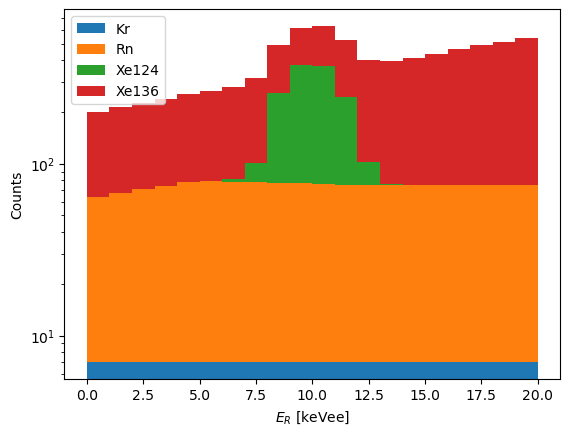

In [3]:
from scipy import integrate

exposure_xlzd = 200. # t yrs

# Definine binning 
bin_edges = np.linspace(0,20, 21, endpoint=True)
nbins = len(bin_edges) - 1
bin_width = bin_edges[1] - bin_edges[0]


bin_centers = np.empty((nbins))
bkg_kr_bins    = np.empty((nbins))
bkg_rn_bins    = np.empty((nbins))
bkg_xe124_bins = np.empty((nbins))
bkg_xe136_bins = np.empty((nbins))

# Integrate diff spectra across bins
dm_rates = np.empty((nbins))
for i in range(nbins):
    # Get bin centers
    bin_centers[i] = (bin_edges[i] + bin_edges[i+1]) / 2

    # Subdivide bin 
    x = np.linspace(bin_edges[i], bin_edges[i+1], 20)

    # Get interpolation of rate in bin window
    bkg_kr_bins[i]    = integrate.trapezoid(bkg_kr_interp(x), x) * exposure_xlzd
    bkg_rn_bins[i]    = integrate.trapezoid(bkg_rn_interp(x), x) * exposure_xlzd
    bkg_xe124_bins[i] = integrate.trapezoid(bkg_xe124_interp(x), x) * exposure_xlzd
    bkg_xe136_bins[i] = integrate.trapezoid(bkg_xe136_interp(x), x) * exposure_xlzd


# Stacked histogram
stacked_bkgs = [bkg_kr_bins, bkg_rn_bins, bkg_xe124_bins, bkg_xe136_bins]

# Plotting
plt.hist(len(stacked_bkgs)*[bin_centers], weights=stacked_bkgs, bins=bin_edges, density=False, stacked=True , histtype='barstacked', log=False, label=["Kr", "Rn", "Xe124", "Xe136"])
plt.yscale('log')
# plt.xscale('log')
plt.xlabel(r"$E_R$ [keVee]")
plt.ylabel("Counts")
plt.legend()

### Produce the signal 

In [4]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe    # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI, SM    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared
from snudd.resolution import Resolution, Convolver # deals with the resolution effects on the rate

In [5]:
from snudd.efficiencies import efficiency_lz_er_WS22, efficiency_lz_er_WS24
from snudd.resolution   import res_lz_er ## not sure if this should be updated 


E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered


# Testing SM frist
sm_model = SM()

# Setting up the target
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 

Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
# XLZD counts
def counts_xlzd(signal, E_Rs, E1, E2):
    exposure_xlzd = 200. # t yrs
    convolution_lz_sig= Convolver(E_Rs, signal , efficiency_lz_er_WS24, res_lz_er)
    
    return convolution_lz_sig.convolved_binned_rate(E1, E2) * exposure_xlzd

In [7]:
# Definine binning 
bin_edges = np.linspace(0,20, 21, endpoint=True)
nbins = len(bin_edges) - 1
bin_width = bin_edges[1] - bin_edges[0]

# Get bin centers
bin_centers = np.empty((nbins))
for i in range(nbins):
    bin_centers[i] = (bin_edges[i] + bin_edges[i+1]) / 2



# counts_sm22 = [counts_lz_ER22(sm_spec_xe, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]
counts_sm = [counts_xlzd(sm_spec_xe, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]

bkg_kr_bins    = [counts_xlzd(bkg_kr_interp(E_Rs*1e6), E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]
bkg_rn_bins    = [counts_xlzd(bkg_rn_interp(E_Rs*1e6), E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]
bkg_xe124_bins = [counts_xlzd(bkg_xe124_interp(E_Rs*1e6), E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]
bkg_xe136_bins = [counts_xlzd(bkg_xe136_interp(E_Rs*1e6), E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers]

stacked_bkgs = [bkg_kr_bins, bkg_rn_bins, bkg_xe124_bins, bkg_xe136_bins]

# Summed background
total_bkg = np.sum(stacked_bkgs,axis=0)

/Users/foldenauer/local/opt/SNuDD/snudd/resolution.py:127: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "


### Plotting the bkg and SM signal

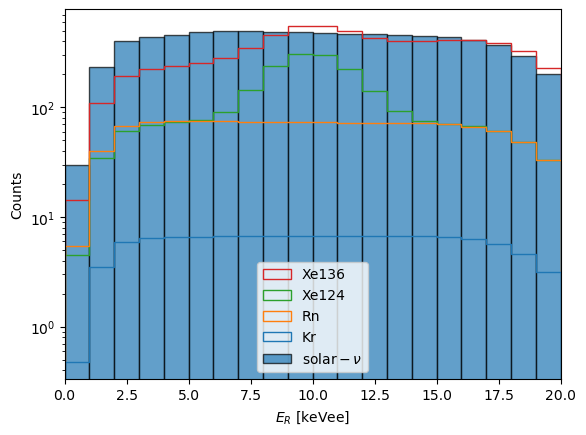

In [8]:

plt.bar(bin_centers, counts_sm, width=bin_width, edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar-}\nu$')

# plt.bar(bin_centers, total_bkg, width=bin_width, edgecolor='black', alpha=0.7, align='center', label=r'Background')

# Plotting
# Plotting
plt.hist(len(stacked_bkgs)*[bin_centers], weights=stacked_bkgs, bins=bin_edges, density=False, stacked=True , histtype='step', log=False, label=["Kr", "Rn", "Xe124", "Xe136"])
plt.yscale('log')
# plt.xscale('log')




plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
# plt.ylim(0,160)
plt.xlim(0.0,20.0)
plt.xlabel(r"$E_R$ [keVee]")
plt.ylabel("Counts")
plt.legend()

plt.show()

## Statistical analysis

We want to calculate the total rate including a NSI signal, for the ith bin, assuming the largest uncertainty comes from the $pp$ flux (1%)

$$N_{\rm pred}^{i}(\Theta; \alpha)= N_{\rm bkg}^{i} + (1+\alpha)N^i_{\rm NSI}(\Theta)$$

where $\Theta$ is the NSI parameters and $\alpha$ is the nuisance parameter of the $pp$ flux. We take the Asimov data set with 

$$N_{\rm data}^{i} = N_{\rm bkg}^{i} + N^i_{\rm NSI}(\Theta)$$

Can define the $\chi^2$ as 

$$\chi^2=2\sum^{\rm bins}_{i=1}\left[N_{\rm pred}^i-N_{\rm data}^{i} + N_{\rm data}^i\ln\left(\frac{N_{\rm data}^i}{N_{\rm pred}^i}\right)\right] + \left(\frac{\alpha}{\sigma_{\alpha}}\right)^2$$


In [9]:
def poisson_chi2_sig(N_nu: np.ndarray, N_bkg: np.ndarray, N_data: np.ndarray, alpha: float = 0.0, sigma_alpha: float = 1.0):
    """
    Compute the Poissonlikelihood-based chi-squared (Cash statistic).

    chi^2 = 2 * sum_i [ N_pred^i - N_data^i + N_data^i * ln(N_data^i / N_pred^i) ] + (alpha / sigma_alpha)^2

    Parameters
    ----------
    N_nu : np.ndarray
        Number of neutrino events in each bin (must be non-negative)
    N_bkg : np.ndarray
        Number of background events in each bin (must be non-negative)
    N_data : np.ndarray
        Observed number of events in each bin (must be non-negative)
    alpha : float, optional
        Nuisance parameter (default: 0.0)
    sigma_alpha : float, optional
        Uncertainty on the nuisance parameter (default: 1.0)

    Returns
    -------
    float
        The chi-squared value
    """
    N_pred = np.atleast_1d((1+alpha)*N_nu + N_bkg)
    N_data = np.atleast_1d(N_data)

    assert len(N_pred) == len(N_data), "N_pred and N_data must have the same length"

    # Handle edge cases:
    # 1. When N_data = 0, the term N_data * ln(N_data / N_pred) -> 0 (limit as x->0 of x*ln x = 0)
    # 2. When N_pred = 0, the log term is problematic - skip these bins
    # 3. Use np.log to compute ln(N_data / N_pred) = ln(N_data) - ln(N_pred)

    valid_mask = N_pred > 0

    if not np.any(valid_mask):
        return np.inf  # all predictions are invalid

    N_pred_valid = N_pred[valid_mask]
    N_data_valid = N_data[valid_mask]

    # Compute term = N_pred - N_data + N_data * ln(N_data / N_pred)
    # For zero bins where N_data = 0, the ln term contributes zero
    term = N_pred_valid - N_data_valid + N_data_valid * (
        np.log(N_data_valid + 1e-300) - np.log(N_pred_valid)  # handles N_data = 0 naturally
    )

    # Sum over bins and multiply by 2
    chi2 = 2.0 * np.sum(term)

    # Add the nuisance parameter penalty term
    chi2 += (alpha / sigma_alpha)**2

    return chi2



def derivative_poisson_chi2_sig(N_nu: np.ndarray, N_bkg: np.ndarray, N_data: np.ndarray, alpha: float = 0.0, sigma_alpha: float = 1.0):
    """
    Compute the derivative of the Poissonlikelihood-based chi-squared (Cash statistic).
    """
    N_nu   = np.atleast_1d(N_nu)
    N_bkg  = np.atleast_1d(N_bkg)
    N_data = np.atleast_1d(N_data)

    assert len(N_nu)  == len(N_data), "N_nu and N_data must have the same length"
    assert len(N_bkg) == len(N_data), "N_nu and N_data must have the same length"

    # Handle edge cases:
    # 2. When N_pred = 0, the log term is problematic - skip these bins

    valid_mask = N_bkg + (1+alpha) * N_nu > 0

    if not np.any(valid_mask):
        return np.inf  # all predictions are invalid

    N_nu_valid   = N_nu[valid_mask]
    N_bkg_valid  = N_bkg[valid_mask]
    N_data_valid = N_data[valid_mask]

    # Compute term = N_pred - N_data + N_data * ln(N_data / N_pred)
    # For zero bins where N_data = 0, the ln term contributes zero
    term = N_nu_valid - N_data_valid * N_nu_valid / (N_bkg_valid + (1+alpha) * N_nu_valid)

    # Sum over bins and multiply by 2
    deriv =  np.sum(term) + alpha / sigma_alpha**2
    deriv *= 2.

    return deriv

## 1D scan 

In [28]:
# Setup scan parameters

# eps_space = np.concatenate( (np.geomspace(1e-2, 8e-1, 60), np.geomspace(8e-1, 3, 500)))  ## ee resonance grid
eps_space = np.geomspace(1e-2, 2e0, 80)
eta = 0.0 # therefore in the proton-neutron plane
phi = -np.pi/2 # therefore in the electron direction   


In [ ]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi):
    
    # eps_matrix = np.array([[0., 1., 0.], [1., 0.0, 0.], [0., 0., 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = np.array([[1., 0., 0.], [0., 0.0, 0.], [0., 0., 0.0]]) * eps # eps_{ee} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix)
    nsi_model = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

### Without profiling

In [21]:
# Initialize a 2D array: shape (n_eps, n_bins)
# counts_all22 = np.zeros((len(eps_space), len(bin_centers)))
counts_all24 = np.zeros((len(eps_space), len(bin_centers)))

for i, eps in enumerate(tqdm(eps_space, desc="Processing eps values")):
    NSI_eps_tmp = eps
    NSI_eta_tmp = eta  # fixed as zero
    NSI_phi_tmp = phi  # fixed as zero

    nsi_temp = set_NSI_params(NSI_eps_tmp, NSI_eta_tmp, NSI_phi_tmp)
    Xe_electron.update_model(nsi_temp)
    Xe_electron.prepare_density()

    signal_temp = Xe_electron.spectrum(E_Rs) 
    # Compute binned counts for this eps value
    # counts_all22[i, :] = np.array([counts_lz_ER22(signal_temp, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers])
    counts_all24[i, :] = np.array([counts_xlzd(signal_temp, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers])


Processing eps values: 100%|██████████| 80/80 [00:41<00:00,  1.91it/s]


In [ ]:
chi2_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    chi2_values[i] = poisson_chi2_sig(counts_all24[i, :], total_bkg, total_bkg+counts_sm)

# print(chi2_values)

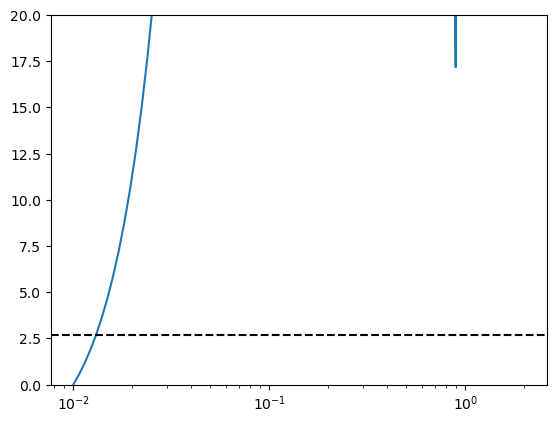

In [23]:
plt.plot(eps_space, chi2_values-np.min(chi2_values))
plt.axhline(2.71, color='k', ls='--')
plt.ylim(0,20)
# plt.xlim(0.8,0.9)
plt.xscale('log')

### With profiling

To marginalize over the nuisance $\alpha$ I need to minimize the $\chi^2$ w.r.t. $\alpha$ 

In [21]:
# pp flux uncertainty
sigma_pp = 0.01

In [16]:
# for a in np.linspace(-1, 1, 11):
    
#     chi2_values = np.zeros(len(eps_space)) 

#     for i in range(len(eps_space)):
#         chi2_values[i] = poisson_chi2_sig(counts_all24[i, :], total_bkg, total_bkg+counts_sm, alpha=a*5*sigma_pp, sigma_alpha=sigma_pp)

#     plt.semilogx(eps_space, chi2_values-np.min(chi2_values), label="a={:.2f}".format(a))

# plt.axhline(2.71, color='k', ls='--')
# plt.ylim(0,50)
# plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
# plt.ylabel(r'$\chi^2 - \chi^2_{\rm min}$', size=14)
# plt.legend()

In [33]:
from scipy.optimize import minimize, minimize_scalar

chi2_alpha_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    # result = minimize_scalar(
    # fun = lambda a: poisson_chi2_sig(counts_all24[i, :], total_bkg, total_bkg+counts_sm, alpha=a, sigma_alpha=sigma_pp), bounds=(-5, 5), method='bounded')
    result = minimize(
        fun = lambda a: poisson_chi2_sig(counts_all24[i, :], total_bkg, total_bkg+counts_sm, alpha=a, sigma_alpha=sigma_pp), 
        x0=0,
        jac = lambda a: derivative_poisson_chi2_sig(counts_all24[i, :], total_bkg, total_bkg+counts_sm, alpha=a, sigma_alpha=sigma_pp), 
        # bounds=(-5, 5), 
        method="L-BFGS-B"
        )
    # print(result.x)
    chi2_alpha_values[i] =  result.fun

print(chi2_alpha_values)


chi2_alpha_min = poisson_chi2_sig(counts_sm, total_bkg, total_bkg+counts_sm, alpha=0, sigma_alpha=sigma_pp)
print(chi2_alpha_min)

[2.68429490e+00 2.83115714e+00 2.98605453e+00 3.14942661e+00
 3.32173696e+00 3.50347448e+00 3.69515483e+00 3.89732181e+00
 4.11054897e+00 4.33544116e+00 4.57263632e+00 4.82280720e+00
 5.08666330e+00 5.36495288e+00 5.65846504e+00 5.96803195e+00
 6.29453121e+00 6.63888830e+00 7.00207918e+00 7.38513305e+00
 7.78913521e+00 8.21523015e+00 8.66462469e+00 9.13859143e+00
 9.63847224e+00 1.01656821e+01 1.07217129e+01 1.13081377e+01
 1.19266152e+01 1.25788941e+01 1.32668182e+01 1.39923314e+01
 1.47574830e+01 1.55644334e+01 1.64154603e+01 1.73129645e+01
 1.82594769e+01 1.92576653e+01 2.03103413e+01 2.14204689e+01
 2.25911713e+01 2.38257405e+01 2.51276454e+01 2.65005417e+01
 2.79482810e+01 2.94749218e+01 3.10847400e+01 3.27822401e+01
 3.45721669e+01 3.64595187e+01 3.84495593e+01 4.05478325e+01
 4.27601758e+01 4.50927357e+01 4.75519828e+01 5.01447290e+01
 5.28781434e+01 5.57597709e+01 5.87975503e+01 6.19998339e+01
 6.53754071e+01 6.89335096e+01 7.26838570e+01 7.66366629e+01
 8.08026628e+01 8.519313

Text(0, 0.5, '$\\chi^2 - \\chi^2_{\\rm min}$')

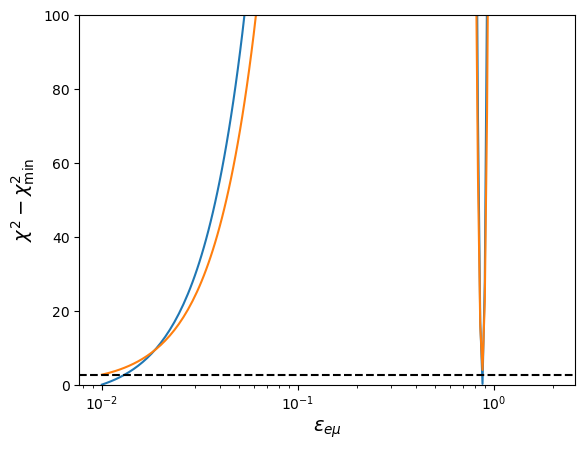

In [37]:
# Find global minimum of chi2_alpha_values and compare with chi2_alpha_sm

plt.semilogx(eps_space, chi2_values-np.min(chi2_values))
plt.semilogx(eps_space, chi2_alpha_values-chi2_alpha_min)

plt.axhline(2.71, color='k', ls='--')

# plt.xlim(5e-2,5e-1)
plt.ylim(0,100)
plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
plt.ylabel(r'$\chi^2 - \chi^2_{\rm min}$', size=14)

## Interference line

In [51]:
from scipy.optimize import minimize_scalar

def local_ll(epsilon, eta, phi):

    nsi_temp = set_NSI_params(epsilon, eta, phi)
    Xe_electron.update_model(nsi_temp)
    Xe_electron.prepare_density()

    signal_temp = Xe_electron.spectrum(E_Rs) 
    # Compute binned counts for this eps value
    counts_all = np.array([counts_xlzd(signal_temp, E_Rs, (bc - bin_width / 2) * 1e-6, (bc + bin_width / 2) * 1e-6) for bc in bin_centers])

    return poisson_chi2_sig(counts_all, total_bkg, total_bkg+counts_sm)



result = minimize_scalar(local_ll, args=(eta,phi), bounds=(0.8, 2.), method='bounded')

print(result)

/Users/foldenauer/local/opt/SNuDD/snudd/resolution.py:127: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "


 message: Solution found.
 success: True
  status: 0
     fun: 3.8325774073566294
       x: 0.87397822281834
     nit: 11
    nfev: 11


### Scanning over $\phi$

In [ ]:
eta_charged = 0
phi_neg = np.linspace(-np.pi/2, -np.pi/16, 30)
phi_pos = - phi_neg[::-1]
eps_neg = np.empty_like(phi_neg)
eps_pos = np.empty_like(phi_neg)

for i, ph in enumerate(tqdm(phi_neg, desc="Processing phi values")):
    result = minimize_scalar(local_ll, args=(eta_charged, ph), bounds=(0.8, 10), method='bounded')
    eps_neg[i] = result.x

for i, ph in enumerate(tqdm(phi_pos, desc="Processing phi values")):
    result = minimize_scalar(local_ll, args=(eta_charged, ph), bounds=(-10, 0.8), method='bounded')
    eps_pos[i] = result.x

Processing phi values:   0%|          | 0/30 [00:00<?, ?it/s]/Users/foldenauer/local/opt/SNuDD/snudd/resolution.py:127: UserWarning: Minimum of supplied recoil energy (0.0) is less than minimum of supplied E_prime (1e-08). Convolution may not be accurate.
  warnings.warn(f"Minimum of supplied recoil energy ({np.min(E_R)}) is less than "
Processing phi values: 100%|██████████| 30/30 [03:25<00:00,  6.86s/it]


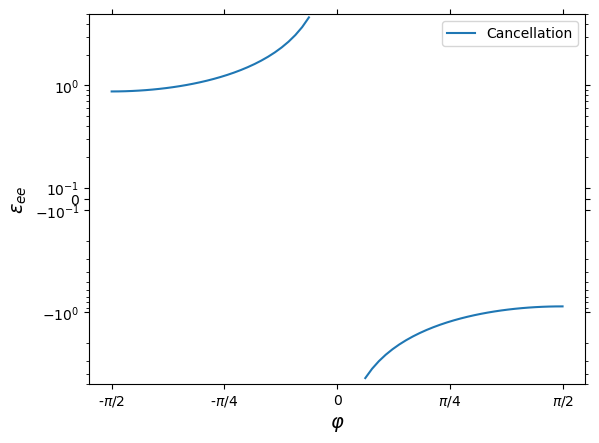

In [53]:

# Figure
fig, ax = plt.subplots()

plt.plot(phi_neg, eps_neg, color='tab:blue', label="Cancellation")
plt.plot(phi_pos, eps_pos, color='tab:blue')
ax.set_yscale('symlog', linthresh=0.1, linscale=0.1)
# ax.yaxis.set_minor_locator(tck.AutoMinorLocator())
ax.set_xticks(np.pi*np.array([-1./2, -1./4, 0, 1./4, 1./2]), [r'-$\pi/2$', r'-$\pi/4$', '0', r'$\pi/4$', r'$\pi/2$'])
ax.set_yticks(np.outer(np.array([ -0.1, -1, 0.1, 1]),np.array([2, 3, 4 , 5, 6, 7, 8, 9])).flatten(), minor=True)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.set_ylim(-5, 5)
plt.xlabel(r'$\varphi$', size=14)
plt.ylabel(r'$\varepsilon_{ee}$', size=14)
plt.legend()
# plt.savefig("eps_emu_LL.png", bbox_inches='tight')

In [56]:
np.savetxt("cancel_ee_phi_neg.csv", np.array([phi_neg, eps_neg]).T, header="phi, eps", delimiter=",")
np.savetxt("cancel_ee_phi_pos.csv", np.array([phi_pos, eps_pos]).T, header="phi, eps", delimiter=",")